# Image Denoising Autoencoder - MNIST

Convolutional autoencoder that learns to remove Gaussian noise from MNIST digit images.

**Pipeline:** load MNIST → add synthetic noise → train conv autoencoder (noisy → clean) → evaluate with visual comparison + PSNR/SSIM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


## 1. Load and preprocess MNIST

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize to [0, 1] and add channel dimension
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, axis=-1)  # (N, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 44s 4us/step
Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## 2. Add synthetic Gaussian noise

We create noisy versions of every image. The autoencoder will be trained to map `noisy -> clean`.

In [3]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy.astype('float32')

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("Noisy train shape:", x_train_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)


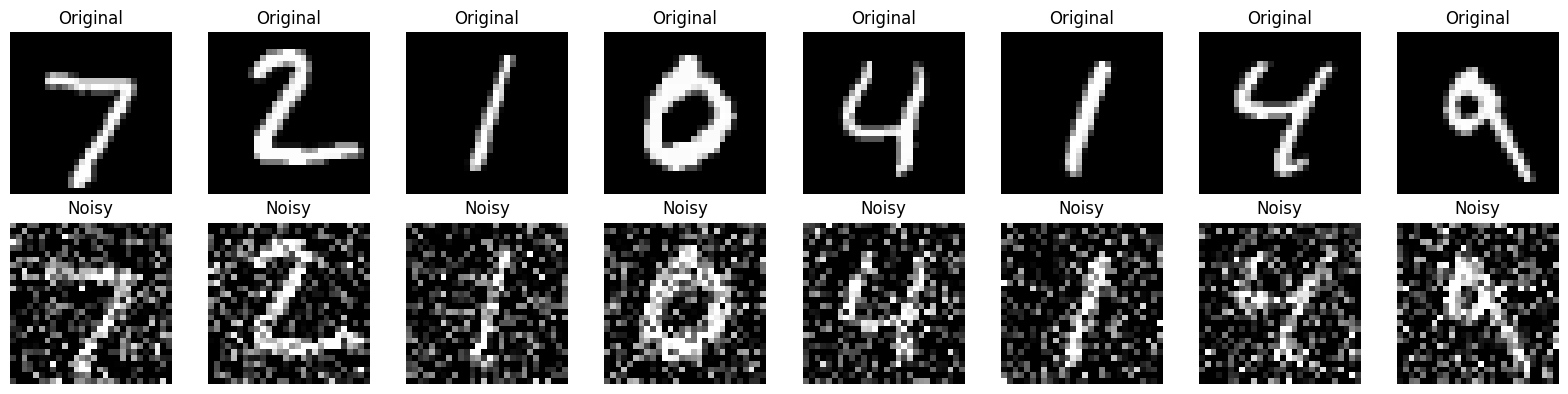

In [4]:
# Preview a few clean vs noisy pairs
n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Build the convolutional autoencoder

- **Encoder:** Conv2D + MaxPooling layers compress the 28x28x1 image down to a compact latent representation.
- **Decoder:** Conv2D + UpSampling layers reconstruct the 28x28x1 image from that representation.
- Output activation is `sigmoid` since pixel values are in `[0, 1]`.

In [5]:
def build_autoencoder():
    input_img = keras.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)          # 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)    # 7x7x32

    # Decoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)                           # 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)                           # 28x28x32
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(input_img, decoded, name='denoising_autoencoder')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train

Input = noisy images, target = original clean images.

In [6]:
EPOCHS = 30
BATCH_SIZE = 128

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 70ms/step - loss: 0.1569 - val_loss: 0.1009
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.0988 - val_loss: 0.0954
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - loss: 0.0947 - val_loss: 0.0925
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.0925 - val_loss: 0.0908
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.0910 - val_loss: 0.0897
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.0900 - val_loss: 0.0888
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - loss: 0.0892 - val_loss: 0.0882
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.0886 - val_loss: 0.0877
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.0881 - val_loss: 0.0872
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 71ms/step - loss: 0.0876 - val_loss: 0.0868
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - loss: 0.0872 - val_loss: 0.0864
Epoch 12/30
469/469 ━━━━━━━━━━

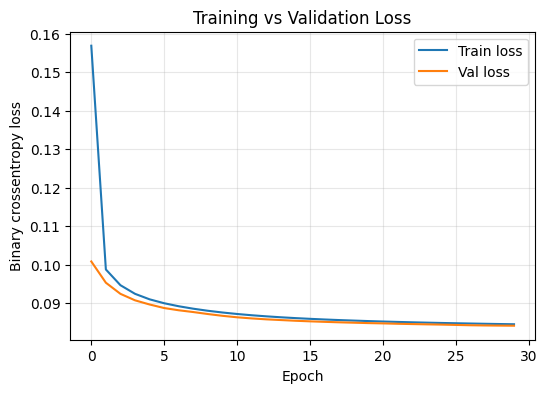

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Binary crossentropy loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Denoise test images and visualize results

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


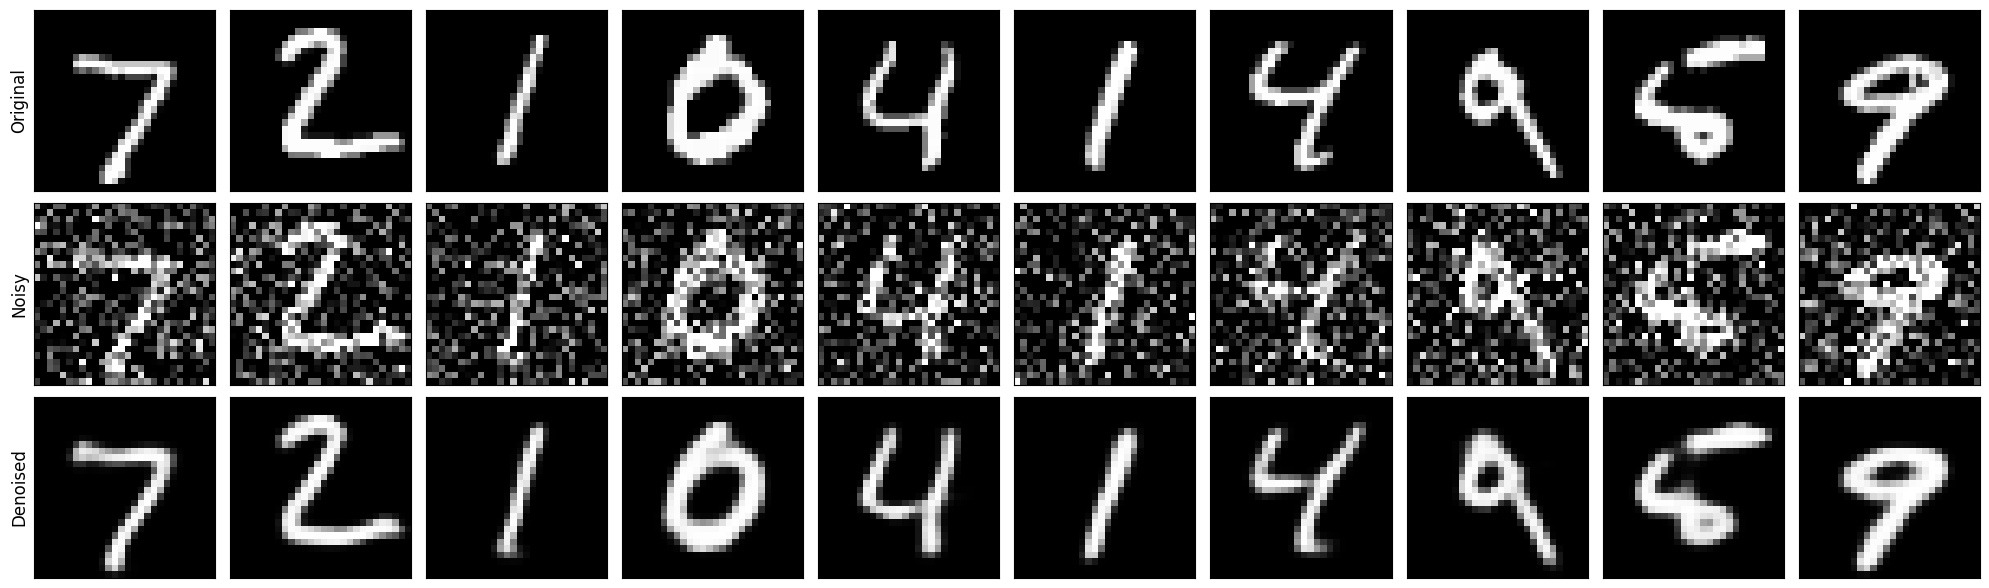

In [8]:
denoised_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel("Original", fontsize=12)
    plt.xticks([]); plt.yticks([])

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel("Noisy", fontsize=12)
    plt.xticks([]); plt.yticks([])

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_imgs[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel("Denoised", fontsize=12)
    plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

## 6. Quantitative evaluation (PSNR & SSIM)

PSNR (Peak Signal-to-Noise Ratio) and SSIM (Structural Similarity Index) measure how close the denoised output is to the ground-truth clean image. Higher is better for both.

In [9]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def evaluate(clean, reconstructed, label):
    psnr_scores = [psnr(clean[i].squeeze(), reconstructed[i].squeeze(), data_range=1.0)
                   for i in range(len(clean))]
    ssim_scores = [ssim(clean[i].squeeze(), reconstructed[i].squeeze(), data_range=1.0)
                   for i in range(len(clean))]
    print(f"{label} -> PSNR: {np.mean(psnr_scores):.2f} dB | SSIM: {np.mean(ssim_scores):.4f}")

evaluate(x_test, x_test_noisy, "Noisy   (before denoising)")
evaluate(x_test, denoised_imgs, "Denoised (after autoencoder)")

Noisy   (before denoising) -> PSNR: 11.00 dB | SSIM: 0.4463
Denoised (after autoencoder) -> PSNR: 21.69 dB | SSIM: 0.9116


## 7. Save the trained model

In [10]:
autoencoder.save('mnist_denoising_autoencoder.keras')
print("Model saved as mnist_denoising_autoencoder.keras")

Model saved as mnist_denoising_autoencoder.keras


## Notes

- **Noise type:** Gaussian noise (`noise_factor=0.4`) added and clipped to `[0, 1]`. Adjust `NOISE_FACTOR` to make the task harder/easier, or swap in salt-and-pepper / speckle noise for variety.
- **Architecture:** symmetric conv encoder-decoder (28x28x1 → 7x7x32 bottleneck → 28x28x1). This is a solid baseline; a deeper network or skip connections (U-Net style) would push PSNR/SSIM higher at the cost of more parameters.
- **Loss:** binary crossentropy works well here since pixels are treated like probabilities in `[0, 1]`; MSE is a reasonable alternative.
- **For the interview / assessment:** be ready to explain why max-pooling + upsampling (rather than plain dense layers) preserves spatial structure, and why the bottleneck forces the network to learn robust, noise-invariant features rather than memorizing pixels.